In [71]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from src import create_journey_features

In [2]:
model = joblib.load('models/xgboost_model2_new_params.joblib')

In [3]:
val_features = pd.read_parquet('data/validation_data2_features.parquet')

In [4]:
X_val = val_features.drop(columns=['id', 'events', 'event_names', 'timestamps', 'outcome', 'start_date', 'end_timestamp', 'current_datetime', 'customer_id'])
y_val = (val_features["outcome"] == 'successful').astype('int')

milestone_days=r"^days_to_milestone_"
X_val = X_val.drop(columns=X_val.columns[X_val.columns.str.contains(milestone_days, regex=True)])

cols = X_val.filter(
    regex=r"^days_between_actions_q_"
).columns
X_val_sub = X_val[cols]
X_val.loc[:, cols] = X_val_sub.where(
    X_val_sub.notna(),
    X_val["days_into_journey"],
    axis=0
)

In [5]:
predictions = model.predict_proba(X_val)[:, 1]

In [17]:
val_features[(val_features['outcome'] == 'successful') & (predictions > 0.9) & (val_features['reached_milestone_4'])].head()

,id,events,event_names,timestamps,journey_length,outcome,start_date,end_timestamp,current_datetime,customer_id,...,reached_milestone_1,reached_milestone_2,reached_milestone_3,reached_milestone_4,reached_milestone_5,days_to_milestone_1,days_to_milestone_2,days_to_milestone_3,days_to_milestone_4,days_to_milestone_5
794,312290252 -591335268,"[19, 19, 19, 19, 19, 3, 19, 1, 5, 6, 19, 19, 1...","[application_web_view, application_web_view, a...","[2023-01-18T16:36:23.000000, 2023-01-18T16:36:...",36,successful,2023-01-18 16:36:23+00:00,2023-03-01 00:00:00+00:00,2023-02-27 00:21:33+00:00,312290252,...,True,True,True,True,True,38.849294,39.080069,38.308067,39.080069,39.308067
2186,-1096387353 -1300973650,"[2, 19, 19, 19, 19, 19, 3, 19, 12, 19, 4, 4, 4...","[campaign_click, application_web_view, applica...","[2021-01-27T06:00:00.000000, 2021-01-27T14:55:...",43,successful,2021-01-27 06:00:00+00:00,2021-03-26 00:00:00+00:00,2021-03-25 06:48:18+00:00,-1096387353,...,True,True,True,True,True,0.373484,53.580336,53.750000,53.580336,55.750000
3087,-1806460767 1512984473,"[2, 12, 4, 4, 4, 4, 1, 4, 4, 4, 4, 11, 5, 6, 8...","[campaign_click, application_web_approved, bro...","[2021-03-05T06:00:00.000000, 2021-03-05T17:21:...",20,successful,2021-03-05 06:00:00+00:00,2021-03-30 00:00:00+00:00,2021-03-28 20:21:17+00:00,-1806460767,...,True,True,True,True,True,0.473287,20.526887,20.750000,20.526887,22.750000
4796,1407584106 1141205669,"[12, 4, 11, 5, 6, 4, 11, 5, 6, 7, 8, 29, 27]","[application_web_approved, browse_products, ad...","[2021-06-30T18:04:35.000000, 2021-06-30T19:55:...",13,successful,2021-06-30 18:04:35+00:00,2021-07-06 00:00:00+00:00,2021-07-04 00:48:24+00:00,1407584106,...,True,True,True,True,True,0.000000,0.084595,0.246817,0.084595,1.246817
7758,789259410 -2116864055,"[1, 13, 19, 2, 4, 11, 7, 5, 19, 6, 3, 29, 2, 8...","[promotion_created, application_web_declined, ...","[2023-03-02T13:31:34.000000, 2023-03-02T13:38:...",21,successful,2023-03-02 13:31:34+00:00,2023-03-17 00:00:00+00:00,2023-03-15 21:15:36+00:00,789259410,...,True,True,True,True,True,12.292500,11.329826,11.436412,12.144965,12.436412


Successful journey example:

Index: 794

id: '312290252 -591335268'

In [18]:
val_df = pd.read_parquet('data/validation_data2.parquet')

In [21]:
sample = val_df.loc[794]

In [64]:
journey_splits = []

n = 1000

for cutoff in (sample.timestamps[0] + np.arange(1, n+1, 1) * (sample.timestamps[-1] - sample.timestamps[0]) / n):
    sample_split = sample.copy()
    sample_split.current_datetime = cutoff
    journey_splits.append(sample_split)

journey_splits_df = pd.concat(journey_splits, axis=1).T.reset_index(drop=True)

In [ ]:
# Update columns in datasets so that they reflect the journey up until the cutoff time
def truncate_journeys(df):
    for i in range(len(df)):
        timestamps = df.at[i, 'timestamps']
        cutoff_time = df.at[i, 'current_datetime']

        cutoff_index = np.searchsorted(timestamps, cutoff_time, side='right')

        df.at[i, 'timestamps'] = timestamps[:cutoff_index]
        df.at[i, 'events'] = df.at[i, 'events'][:cutoff_index]
        df.at[i, 'event_names'] = df.at[i, 'event_names'][:cutoff_index]
        df.at[i, 'journey_length'] = cutoff_index

truncate_journeys(journey_splits_df)

In [80]:
journey_splits_df['current_datetime'] = journey_splits_df['current_datetime'].apply(lambda x: pd.Timestamp(x, tz='UTC'))

In [84]:
journey_splits_df.to_parquet("data/successful_journey_sample.parquet", index=False)

In [85]:
create_journey_features("data/successful_journey_sample.parquet", "successful_journey_sample_features")

Creating Features for data
--------------------------
Successfully read in files.
Added date and previous journey information.
Added number of days since the journey began.
Added last event in journey
Added number of days since last event.
Added days since last user action
Added quantiles for the number of days between actions in the journey.
Added first event id in journey.
Added number of occurrences for repeatable events.
Added indicator for whether each milestone was reached.
Added the number of days until each milestone was achieved during the journey.
Successfully created parquet file.


In [86]:
sample_features = pd.read_parquet("data/successful_journey_sample_features.parquet")

In [89]:
X_val = sample_features.drop(columns=['id', 'events', 'event_names', 'timestamps', 'outcome', 'start_date', 'end_timestamp', 'current_datetime', 'customer_id'])
y_val = (sample_features["outcome"] == 'successful').astype('int')

milestone_days=r"^days_to_milestone_"
X_val = X_val.drop(columns=X_val.columns[X_val.columns.str.contains(milestone_days, regex=True)])

cols = X_val.filter(
    regex=r"^days_between_actions_q_"
).columns
X_val_sub = X_val[cols]
X_val.loc[:, cols] = X_val_sub.where(
    X_val_sub.notna(),
    X_val["days_into_journey"],
    axis=0
)

In [95]:
pred_probs = model.predict_proba(X_val)[:, 1]

In [140]:
importances = model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        "feature": X_val.columns,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df[:15]

,feature,importance
0,reached_milestone_4,0.357599
1,event_8_count,0.151162
2,days_since_last_user_event,0.104160
3,days_between_actions_q_95,0.088100
4,reached_milestone_5,0.034319
5,days_since_last_event,0.021570
6,reached_milestone_1,0.021381
7,days_between_actions_q_90,0.019486
8,event_12_count,0.017102
9,event_4_count,0.015981


In [148]:
notable_event_ids = [4, 8, 12, 27, 29]

In [149]:
notable_event_indices = np.where(np.isin(sample_features.loc[999, 'events'], notable_event_ids))[0]
notable_timestamps = sample_features.loc[999, 'timestamps'][notable_event_indices]

In [150]:
probs = []

for timestamp in notable_timestamps:
    index = sample_features[sample_features['current_datetime'] <= pd.Timestamp(timestamp, tz='UTC')].shape[0]
    probs.append(pred_probs[min(n-1, index)])

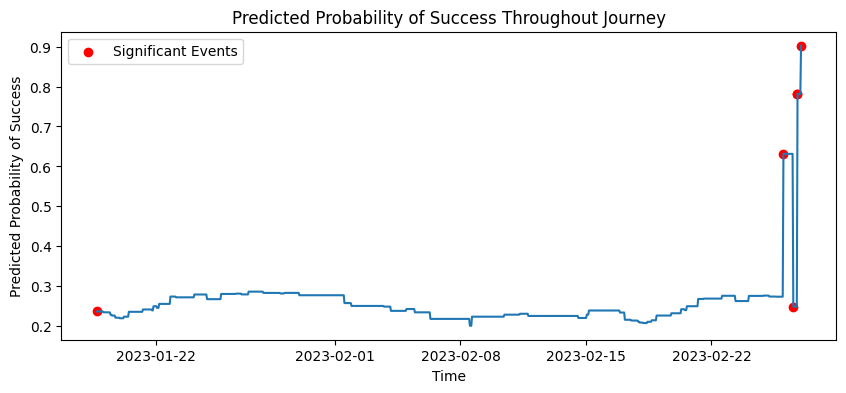

In [151]:
plt.figure(figsize=(10, 4))
plt.plot(sample_features['current_datetime'], pred_probs)
plt.scatter(notable_timestamps, probs, c='red', label='Significant Events')
plt.xlabel('Time')
plt.ylabel('Predicted Probability of Success')
plt.title('Predicted Probability of Success Throughout Journey')
plt.legend()
plt.show()

In [152]:
sample_features.loc[999, 'events'][notable_event_indices]

array([ 4, 29, 12,  8,  4, 27])

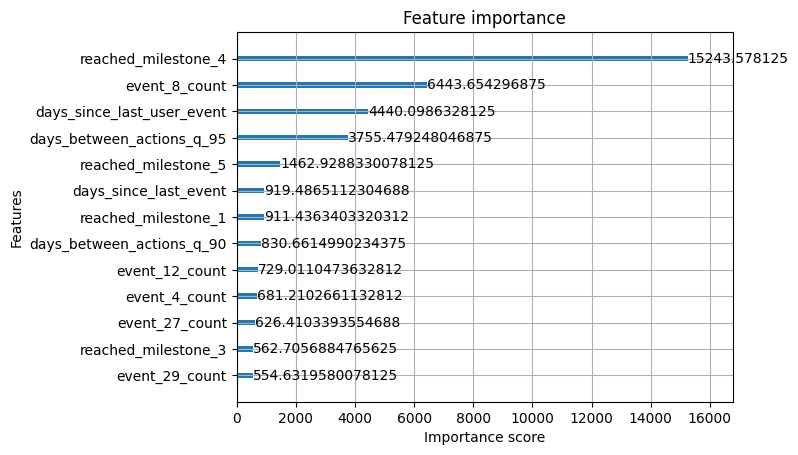

In [154]:
from xgboost import plot_importance

plot_importance(model, importance_type="gain", max_num_features=13)
plt.show()